In [0]:
from pyspark.sql.functions import col, max as spark_max, datediff, lit, when
from pyspark.sql.types import IntegerType

storage_account     = "stfintechpipeline"
storage_account_key = "YOUR_ACCESS_KEY_HERE"

spark.conf.set(
    f"fs.azure.account.key.{storage_account}.dfs.core.windows.net",
    storage_account_key
)

CURATED = f"abfss://curated@{storage_account}.dfs.core.windows.net"

In [0]:
customer_features = spark.read.parquet(f"{CURATED}/customer_features/")

print(f"Rows    : {customer_features.count():,}")
print(f"Columns : {len(customer_features.columns)}")
customer_features.printSchema()

Rows    : 1,219
Columns : 42
root
 |-- client_id: integer (nullable = true)
 |-- total_transaction_count: long (nullable = true)
 |-- total_spend: double (nullable = true)
 |-- avg_spend_per_transaction: double (nullable = true)
 |-- days_since_last_transaction: integer (nullable = true)
 |-- avg_days_between_transactions: double (nullable = true)
 |-- unique_merchant_count: long (nullable = true)
 |-- unique_merchant_category_count: long (nullable = true)
 |-- top_merchant_category: string (nullable = true)
 |-- error_count: long (nullable = true)
 |-- error_rate: double (nullable = true)
 |-- insufficient_balance_count: long (nullable = true)
 |-- pct_fraud_transactions: double (nullable = true)
 |-- has_fraud_history: boolean (nullable = true)
 |-- transaction_frequency_trend: double (nullable = true)
 |-- pct_weekend_transactions: double (nullable = true)
 |-- pct_online_transactions: double (nullable = true)
 |-- most_common_hour: integer (nullable = true)
 |-- pct_home_state_tran

#Section 1
churn label investigation
3 approaches attempted. all produced unusable labels
finding: dataset does not support threshold-based churn

In [0]:
customer_features.select("days_since_last_transaction") \
    .summary("min", "25%", "50%", "75%", "max") \
    .show()

customer_features.groupBy(
    when(col("days_since_last_transaction") < 30, "Under 30 days")
    .when(col("days_since_last_transaction") < 60, "30-59 days")
    .when(col("days_since_last_transaction") < 90, "60-89 days")
    .when(col("days_since_last_transaction") < 180, "90-179 days")
    .otherwise("180+ days")
    .alias("inactivity_band")
).count().orderBy("inactivity_band").show()

+-------+---------------------------+
|summary|days_since_last_transaction|
+-------+---------------------------+
|    min|                          0|
|    25%|                          0|
|    50%|                          0|
|    75%|                          0|
|    max|                       2464|
+-------+---------------------------+

+---------------+-----+
|inactivity_band|count|
+---------------+-----+
|      180+ days|   13|
|     30-59 days|    3|
|  Under 30 days| 1203|
+---------------+-----+



from this we can see that 98.7% of customers have days until last transaction = 0. Only 13 customers qualify as churned under 60-day thresholed. Dataset decade's long growth trend means most customers transacted right up to the dataset end date

In [0]:
from pyspark.sql.functions import col, when

#Churn Label Attempt 2: Transaction Frequency Drop
customer_features.select("transaction_frequency_trend") \
    .summary("min", "25%", "50%", "75%", "max") \
    .show()

customer_features.groupBy(
    when(col("transaction_frequency_trend") < 0.5,  "Severe drop (<0.5)")
    .when(col("transaction_frequency_trend") < 0.75, "Moderate drop (0.5-0.75)")
    .when(col("transaction_frequency_trend") < 1.0,  "Slight drop (0.75-1.0)")
    .when(col("transaction_frequency_trend") < 1.25, "Stable (1.0-1.25)")
    .otherwise("Growing (1.25+)")
    .alias("frequency_band")
).count().orderBy("frequency_band").show()

+-------+---------------------------+
|summary|transaction_frequency_trend|
+-------+---------------------------+
|    min|                        0.0|
|    25%|                     0.9667|
|    50%|                     1.0206|
|    75%|                     1.0762|
|    max|                     7.5591|
+-------+---------------------------+

+--------------------+-----+
|      frequency_band|count|
+--------------------+-----+
|     Growing (1.25+)|   23|
|Moderate drop (0....|    9|
|  Severe drop (<0.5)|   13|
|Slight drop (0.75...|  460|
|   Stable (1.0-1.25)|  714|
+--------------------+-----+



from this we can see that 96.3% of customers are stable or growing in transaction frequency. only 22 customers show moderate or severe drops
Dataset growth trend throughout the 2010s makes frequency comparison
between recent and historical periods unreliable — recent is always higher

In [0]:
# — Churn Label Attempt 3: 180-Day Rule from raw transactions
# Completely independent of customer_features engineered columns
# A customer is churned if:
# 1. Last transaction was 180+ days before dataset end date AND
# 2. Transaction count in final 6 months is less than 50% 
#    of their historical monthly average

from pyspark.sql.functions import (
    col, max as spark_max, min as spark_min, 
    count, datediff, lit, to_date, when,
    avg, round as spark_round
)
from pyspark.sql.window import Window

#read cleaned transactions directly
CLEANED = f"abfss://cleaned@{storage_account}.dfs.core.windows.net"

df_txn_raw = spark.read.parquet(f"{CLEANED}/transactions_data/")
#define dataset end date
DATASET_END = to_date(lit("2019-10-31"))
#calculate per customer:
#days since last transaction, total months active, historical monthly average transaction count, transaction count in final 6 months

#total transactions and date range per customer
customer_stats = df_txn_raw.groupBy("client_id").agg(
    spark_max(to_date(col("transaction_date"))).alias("last_transaction_date"),
    spark_min(to_date(col("transaction_date"))).alias("first_transaction_date"),
    count("*").alias("total_txn_count")
)

#days since last transaction
customer_stats = customer_stats.withColumn(
    "days_since_last_txn",
    datediff(DATASET_END,col("last_transaction_date"))
)

#total months active
customer_stats = customer_stats.withColumn(
    "active_months",
    (datediff(col("last_transaction_date"),
              col("first_transaction_date"))/30).cast("integer")
)

#historical monthly average
customer_stats=customer_stats.withColumn(
    "historical_monthly_avg",
    when(col("active_months")==0, col("total_txn_count"))
    .otherwise(
        spark_round(col("total_txn_count")/col("active_months"))
    )
)

#count transactions in the final 6 months per customer
SIXMONTHS_AGO = to_date(lit("2019-04-30"))
recent_txn=df_txn_raw\
    .filter(to_date(col("transaction_date"))>=SIXMONTHS_AGO)\
    .groupBy("client_id")\
    .agg(count("*").alias("recent_6m_txn_count"))

#join recent counts back
customer_stats=customer_stats.join(recent_txn, on="client_id", how="left").fillna(0, subset=["recent_6m_txn_count"])



In [0]:
#cal recent monthly rate
customer_stats=customer_stats.withColumn(
    "recent_monthly_rate",
    spark_round(col("recent_6m_txn_count")/6,2)
)

#apply churn rule
#customer is churned if inactive 180+ days and recent rate <50% of historical average
customer_stats=customer_stats.withColumn(
    "is_churned",
    when(
        (col("days_since_last_txn")>=180)|
        (col("recent_monthly_rate")< col("historical_monthly_avg")*0.5),1
    ).otherwise(0)
)

#check distribution
print("Churn Label Distribution")
customer_stats.groupBy("is_churned").count().orderBy("is_churned").show()

total = customer_stats.count()
print("Churn Label Percentage")
customer_stats.groupBy("is_churned") \
    .count() \
    .withColumn("percentage",
        spark_round(col("count") / total * 100, 2)) \
    .orderBy("is_churned") \
    .show()
#preview
print("=== Sample Customer Stats ===")
customer_stats.select(
    "client_id", "days_since_last_txn", 
    "historical_monthly_avg", "recent_monthly_rate", 
    "is_churned"
).show(10)

Churn Label Distribution
+----------+-----+
|is_churned|count|
+----------+-----+
|         0| 1206|
|         1|   13|
+----------+-----+

Churn Label Percentage
+----------+-----+----------+
|is_churned|count|percentage|
+----------+-----+----------+
|         0| 1206|     98.93|
|         1|   13|      1.07|
+----------+-----+----------+

=== Sample Customer Stats ===
+---------+-------------------+----------------------+-------------------+----------+
|client_id|days_since_last_txn|historical_monthly_avg|recent_monthly_rate|is_churned|
+---------+-------------------+----------------------+-------------------+----------+
|     1591|                  0|                 184.0|             200.33|         0|
|     1645|                  0|                  78.0|              86.67|         0|
|     1959|                  0|                  44.0|              46.67|         0|
|      148|                  0|                  93.0|              95.17|         0|
|      496|             

from this we can see that only 13 customers labelled as churned
The dataset's natural growth trend means recent transaction rates
are almost always higher than historical averages

#Section 2- feature analysis
correlation analysis + PCA investigation

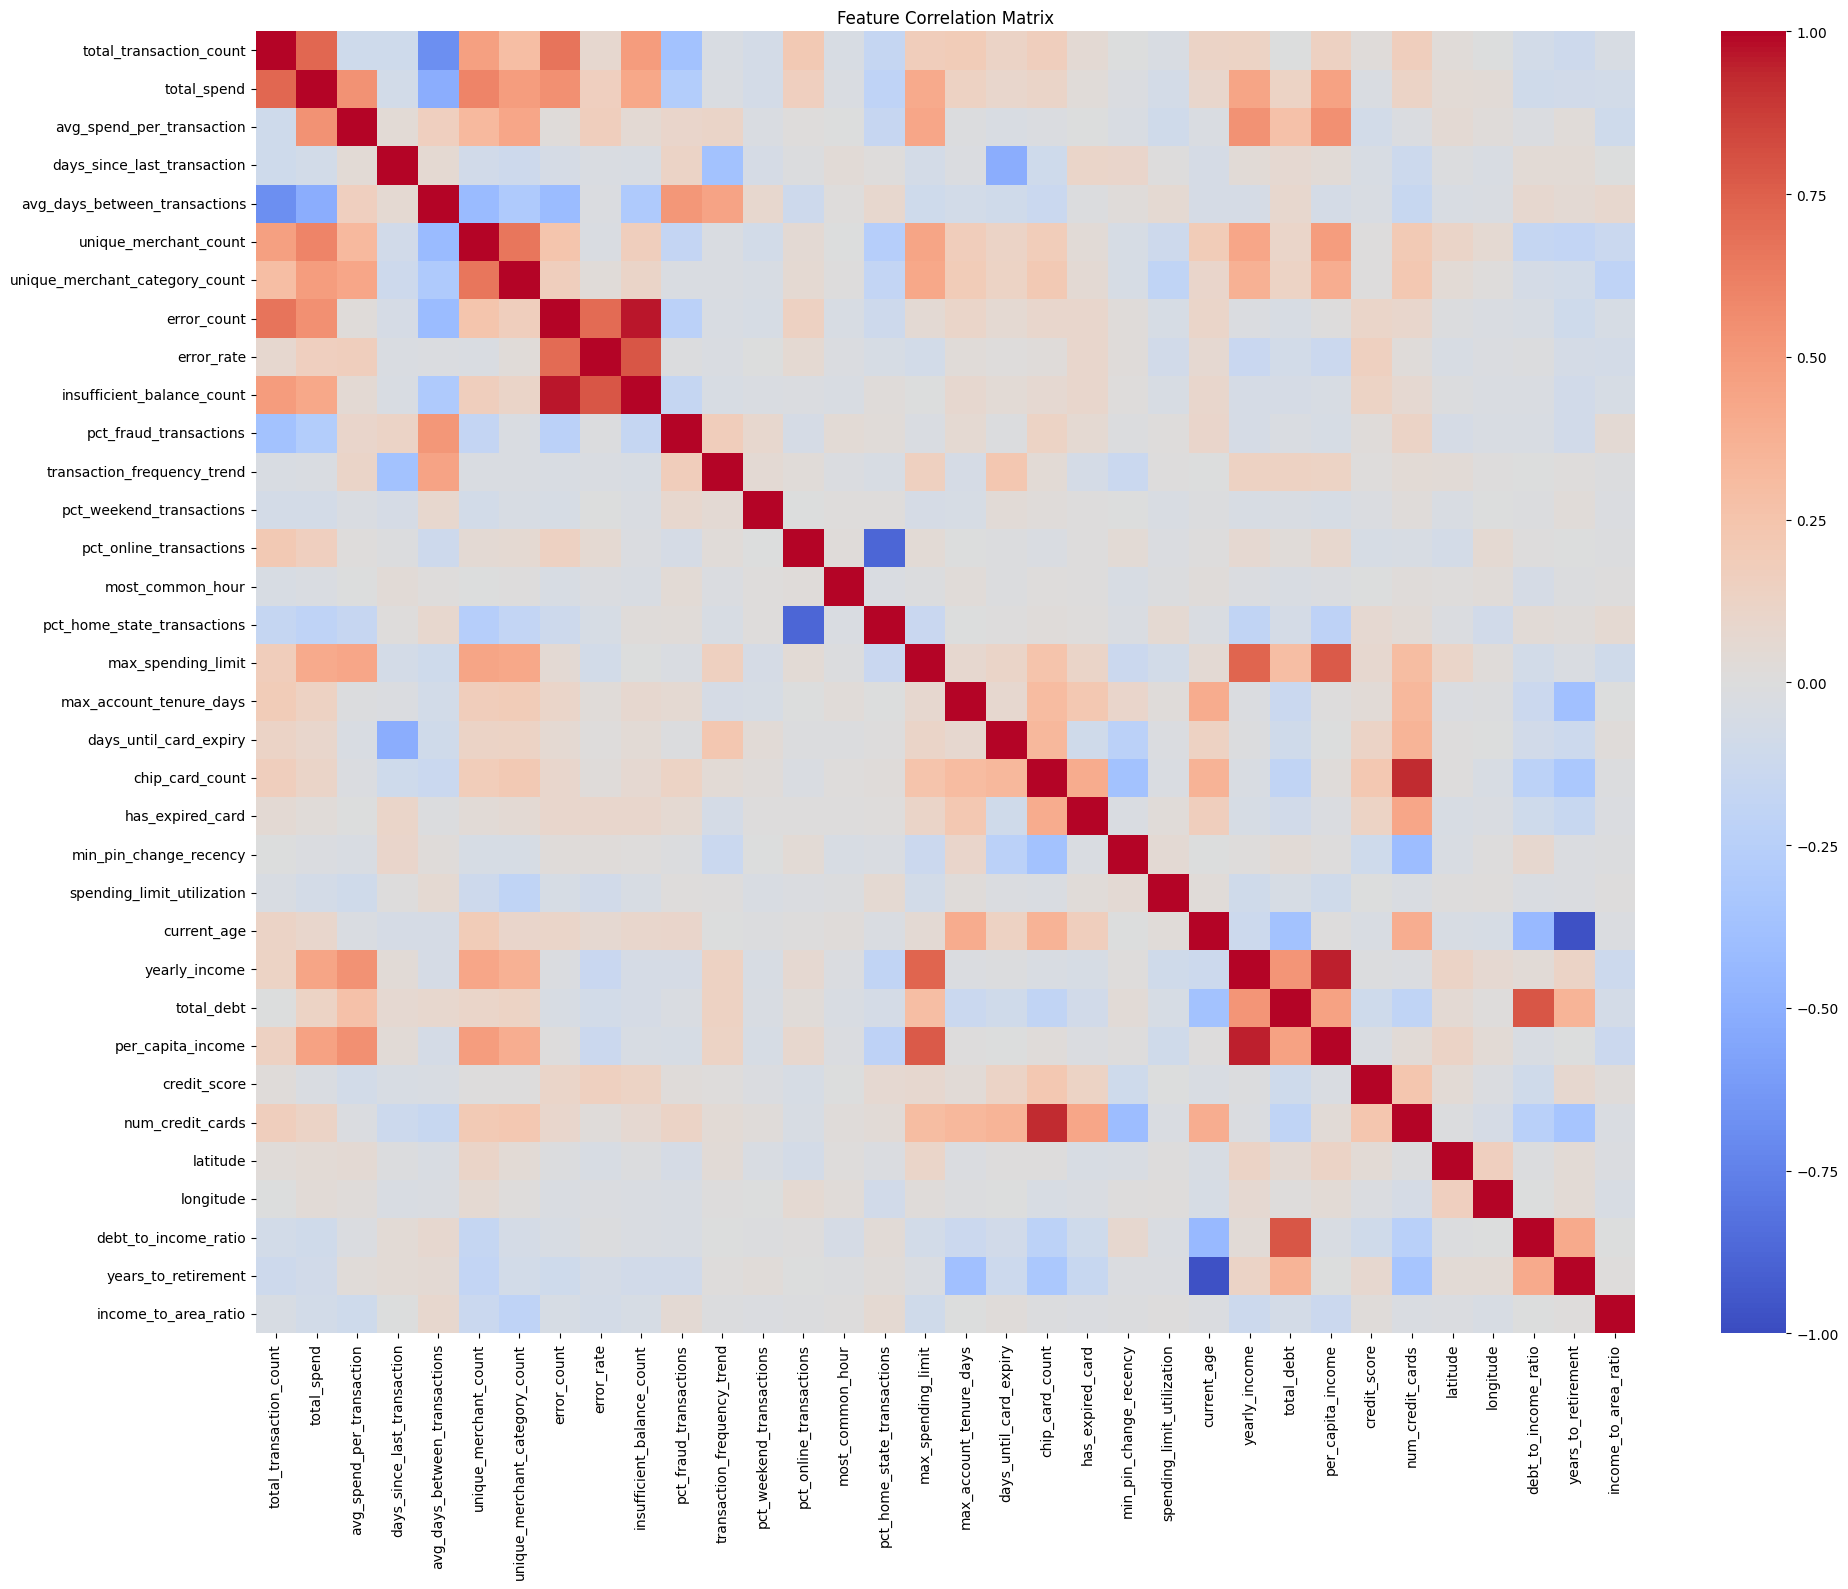


Highly correlated feature pairs (|correlation| > 0.85):
error_count — insufficient_balance_count : 0.964
pct_online_transactions — pct_home_state_transactions : -0.879
chip_card_count — num_credit_cards : 0.923
current_age — years_to_retirement : -0.975
yearly_income — per_capita_income : 0.951


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# select numerical columns for correlation, exclude client_id and boolean columns
exclude_cols = ["client_id", "has_fraud_history", "has_both_card_types", "top_merchant_category", "gender","credit_score_band", "age_group", "debt_to_income_band"]
numerical_cols = [c for c in customer_features.columns if c not in exclude_cols]
# convert to pandas for correlation calculation
df_pd = customer_features.select(numerical_cols).fillna(0).toPandas()
# correlation matrix
corr_matrix = df_pd.corr()
# heatmap
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0,vmin=-1,vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# show highly correlated pairs >0.85
print("\nHighly correlated feature pairs (|correlation| > 0.85):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"{corr_matrix.columns[i]} — {corr_matrix.columns[j]} : {corr_matrix.iloc[i, j]:.3f}")

from this we drop one from each highly correlated pair
error_count  → DROP (keep error_rate + insufficient_balance_count)
pct_home_state_transactions → DROP (keep pct_online_transactions)
chip_card_count → DROP (keep num_credit_cards)
years_to_retirement→ DROP (keep current_age)
per_capita_income → DROP (keep yearly_income)
Remaining features: 31

In [0]:
from pyspark.ml.feature import PCA
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.sql.functions import avg, round as spark_round, col, when
from pyspark.sql.types import IntegerType

#second approach is PCA 
#define the 30 features after dropping correlated ones
features_pca_test = [
    "total_transaction_count", "total_spend", "avg_spend_per_transaction",
    "days_since_last_transaction", "avg_days_between_transactions",
    "unique_merchant_count", "unique_merchant_category_count",
    "error_rate", "insufficient_balance_count", "pct_fraud_transactions",
    "transaction_frequency_trend", "pct_weekend_transactions",
    "pct_online_transactions", "most_common_hour",
    "max_spending_limit", "max_account_tenure_days",
    "days_until_card_expiry", "has_expired_card",
    "min_pin_change_recency", "spending_limit_utilization",
    "current_age", "yearly_income", "total_debt",
    "credit_score", "num_credit_cards", "latitude", "longitude",
    "debt_to_income_ratio", "income_to_area_ratio",
    "has_both_card_types", "gender_encoded"
]
# cast booleans to integer
df_pca_test = customer_features \
    .withColumn("has_expired_card",
                col("has_expired_card").cast(IntegerType()))\
    .withColumn("has_both_card_types",
                col("has_both_card_types").cast(IntegerType()))\
    .withColumn("has_fraud_history",
                col("has_fraud_history").cast(IntegerType()))\
    .withColumn("gender_encoded",
        when(col("gender") == "Male", 1).otherwise(0)) \
    .fillna(0)
#combine and scale
assembler_pca = VectorAssembler(inputCols = features_pca_test, outputCol="features_pca")
df_pca_test = assembler_pca.transform(df_pca_test)

scaler_a = StandardScaler(inputCol="features_pca", outputCol="features_pca_scaled")
df_pca_test = scaler_a.fit(df_pca_test).transform(df_pca_test)

#run PCA on the already scaled features 
#start with enough components to explain 85-90% variance
pca = PCA(k=10, inputCol ="features_pca_scaled", outputCol="pca_features")
pca_model = pca.fit(df_pca_test)
#check how much variance each component explains
explained_variance = pca_model.explainedVariance
cumulative_variance = 0
print("explained variance per component")
for i, var in enumerate(explained_variance):
  cumulative_variance +=var
  print(f"component {i+1}: {var:.4f} | cumulative: {cumulative_variance:.4f}")
  if cumulative_variance >=0.90:
    print(f"\n90% variance explained by {i+1} components")
    break

explained variance per component
component 1: 0.1413 | cumulative: 0.1413
component 2: 0.0985 | cumulative: 0.2397
component 3: 0.0803 | cumulative: 0.3201
component 4: 0.0587 | cumulative: 0.3788
component 5: 0.0563 | cumulative: 0.4351
component 6: 0.0501 | cumulative: 0.4852
component 7: 0.0405 | cumulative: 0.5257
component 8: 0.0366 | cumulative: 0.5623
component 9: 0.0347 | cumulative: 0.5970
component 10: 0.0345 | cumulative: 0.6315


from this we can see that after 10 components only 63% variance is explained
variance is distributed evenly-no dominant component exists an indication that features are independent of each other
PCA cannot compress the dataset meaningfully without information loss
so we skip PCA.

#Section 3- cusomter segmentation
K-Means clustering

In [0]:

# approach one is to apply correlation-filtered features directly into KMeans

#define the 30 features after dropping correlated ones
features_a = [
    "total_transaction_count", "total_spend", "avg_spend_per_transaction",
    "days_since_last_transaction", "avg_days_between_transactions",
    "unique_merchant_count", "unique_merchant_category_count",
    "error_rate", "insufficient_balance_count", "pct_fraud_transactions",
    "transaction_frequency_trend", "pct_weekend_transactions",
    "pct_online_transactions", "most_common_hour",
    "max_spending_limit", "max_account_tenure_days",
    "days_until_card_expiry", "has_expired_card",
    "min_pin_change_recency", "spending_limit_utilization",
    "current_age", "yearly_income", "total_debt",
    "credit_score", "num_credit_cards", "latitude", "longitude",
    "debt_to_income_ratio", "income_to_area_ratio",
    "has_both_card_types", "gender_encoded"
]
# cast booleans to integer
df_ml = customer_features \
    .withColumn("has_expired_card",
                col("has_expired_card").cast(IntegerType()))\
    .withColumn("has_both_card_types",
                col("has_both_card_types").cast(IntegerType()))\
    .withColumn("has_fraud_history",
                col("has_fraud_history").cast(IntegerType()))\
    .withColumn("gender_encoded",
        when(col("gender") == "Male", 1).otherwise(0)) \
    .fillna(0)
#combine and scale
combined_a = VectorAssembler(inputCols = features_a, outputCol="features_a")
df_a = combined_a.transform(df_ml)

scaler_a = StandardScaler(inputCol="features_a", outputCol="features_a_scaled")
df_a = scaler_a.fit(df_a).transform(df_a)

print(f"Features assembled and scaled: {len(features_a)} features")

Features assembled and scaled: 31 features


In [0]:
#kmeans using k= 2
kmeans_a = KMeans(featuresCol= "features_a_scaled", predictionCol="cluster_a",k=2,seed=42)
model_a = kmeans_a.fit(df_a)
df_a= model_a.transform(df_a)
# evalaute clusters
print("Kmeans k=2 cluster sizes:")
df_a.groupBy("cluster_a").count().orderBy("cluster_a").show()
print("cluster centroids:")
df_a.groupBy("cluster_a").agg(
    spark_round(avg("total_transaction_count"), 1).alias("avg_txn_count"),
    spark_round(avg("days_since_last_transaction"), 1).alias("avg_days_inactive"),
    spark_round(avg("transaction_frequency_trend"), 4).alias("avg_freq_trend"),
    spark_round(avg("avg_spend_per_transaction"), 2).alias("avg_spend"),
    spark_round(avg("error_rate"), 4).alias("avg_error_rate"),
    spark_round(avg("insufficient_balance_count"), 2).alias("avg_insuff_balance"),
    spark_round(avg("pct_fraud_transactions"), 4).alias("avg_pct_fraud")
).orderBy("cluster_a").show()


Kmeans k=2 cluster sizes:
+---------+-----+
|cluster_a|count|
+---------+-----+
|        0|  517|
|        1|  702|
+---------+-----+

cluster centroids:
+---------+-------------+-----------------+--------------+---------+--------------+------------------+-------------+
|cluster_a|avg_txn_count|avg_days_inactive|avg_freq_trend|avg_spend|avg_error_rate|avg_insuff_balance|avg_pct_fraud|
+---------+-------------+-----------------+--------------+---------+--------------+------------------+-------------+
|        0|      14461.8|              1.2|        1.0184|    50.61|        0.0162|            148.34|       9.0E-4|
|        1|       8303.7|             23.6|        1.0266|    38.98|        0.0152|             78.25|       0.0015|
+---------+-------------+-----------------+--------------+---------+--------------+------------------+-------------+



from this we can see that k=2, cluster 0 has higher activity but also higher errors. Cluster 1 has lower activity but lower errors. no clean separation between churned and actived behavior


In [0]:
#use k=3 to see the output of the clusters
kmeans_a_k3 = KMeans(featuresCol="features_a_scaled", predictionCol="cluster_a_k3", k=3, seed=42)
model_a_k3 = kmeans_a_k3.fit(df_a)
df_a = model_a_k3.transform(df_a)

print("k=3 — Cluster Sizes")
df_a.groupBy("cluster_a_k3").count().orderBy("cluster_a_k3").show()

print("k=3 — Cluster Centroids")
df_a.groupBy("cluster_a_k3").agg(
    spark_round(avg("total_transaction_count"), 1).alias("avg_txn_count"),
    spark_round(avg("days_since_last_transaction"), 1).alias("avg_days_inactive"),
    spark_round(avg("transaction_frequency_trend"), 4).alias("avg_freq_trend"),
    spark_round(avg("avg_spend_per_transaction"), 2).alias("avg_spend"),
    spark_round(avg("error_rate"), 4).alias("avg_error_rate"),
    spark_round(avg("insufficient_balance_count"), 2).alias("avg_insuff_balance"),
    spark_round(avg("pct_fraud_transactions"), 4).alias("avg_pct_fraud")
).orderBy("cluster_a_k3").show()

k=3 — Cluster Sizes
+------------+-----+
|cluster_a_k3|count|
+------------+-----+
|           0|  429|
|           1|  512|
|           2|  278|
+------------+-----+

k=3 — Cluster Centroids
+------------+-------------+-----------------+--------------+---------+--------------+------------------+-------------+
|cluster_a_k3|avg_txn_count|avg_days_inactive|avg_freq_trend|avg_spend|avg_error_rate|avg_insuff_balance|avg_pct_fraud|
+------------+-------------+-----------------+--------------+---------+--------------+------------------+-------------+
|           0|       7409.4|             38.5|        1.0321|    40.88|        0.0147|             64.35|       0.0014|
|           1|      11014.0|              0.1|        1.0148|    39.39|        0.0162|            114.47|       0.0014|
|           2|      16144.3|              2.2|        1.0246|    56.91|         0.016|            163.32|       7.0E-4|
+------------+-------------+-----------------+--------------+---------+--------------+--

segment interpretation
Cluster 0- voluntary disengagers(429 customers)
 • Fewest transactions: 7,409 avg
  • Most inactive: 38.5 days avg since last transaction
  • Low error rate: not financially stressed
  • Interpretation: customers drifting away quietly
  • Bank action: Proactive retention outreach, win-back offers

Cluster 1 — FINANCIALLY STRESSED ACTIVES (512 customers, 42%)
  • Mid transactions: 11,014 avg
  • Almost zero inactivity: 0.1 days avg
  • Highest error rate and insufficient balance count
  • Interpretation: still transacting but under financial pressure
  • Bank action: Financial wellness products, credit limit review

Cluster 2 — POWER USERS (278 customers, 23%)
  • Highest transactions: 16,144 avg
  • Highest spend: $56.91 avg per transaction
  • Lowest fraud percentage
  • Interpretation: most valuable, most engaged customers
  • Bank action: Loyalty rewards, premium card upgrades

k=3 selected over k=2 because it produces three genuinely
distinct and business-interpretable customer profiles


# Section 4- supervised modelling

In [0]:
#assign churn label from first approach k=3
# Cluster 0 = churned (voluntary disengagement)
# Cluster 1 = active (financially stressed but still transacting)
# Cluster 2 = active (power users)

from pyspark.sql.functions import when, col
df_labelled = df_a.withColumn("is_churned",
                              when(col("cluster_a_k3")== 0,1).otherwise(0))
#class distribution
print("churn lable distribution")
df_labelled.groupBy("is_churned").count().orderBy("is_churned").show()
#percentage
total = df_labelled.count()
print("churn label percentage")
df_labelled.groupBy("is_churned")\
  .count()\
    .withColumn("percentage",
                spark_round(col("count")/total *100,2))\
    .orderBy("is_churned")\
    .show()

churn lable distribution
+----------+-----+
|is_churned|count|
+----------+-----+
|         0|  790|
|         1|  429|
+----------+-----+

churn label percentage
+----------+-----+----------+
|is_churned|count|percentage|
+----------+-----+----------+
|         0|  790|     64.81|
|         1|  429|     35.19|
+----------+-----+----------+



In [0]:
df_ml.select("top_merchant_category").distinct().count()
df_ml.select("top_merchant_category").distinct().show()

+---------------------+
|top_merchant_category|
+---------------------+
|      Wholesale Clubs|
| Women's Ready-To-...|
+---------------------+



In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

#feature preparation for supervised modelling

#select final feature columns
# is_churned is the label, client_id is identifier — both excluded

model_features = [
    "total_transaction_count", "total_spend", "avg_spend_per_transaction",
    "days_since_last_transaction", "avg_days_between_transactions",
    "unique_merchant_count", "unique_merchant_category_count",
    "error_rate", "insufficient_balance_count", "pct_fraud_transactions",
    "transaction_frequency_trend", "pct_weekend_transactions",
    "pct_online_transactions", "most_common_hour",
    "max_spending_limit", "max_account_tenure_days",
    "days_until_card_expiry", "has_expired_card",
    "min_pin_change_recency", "spending_limit_utilization",
    "current_age", "yearly_income", "total_debt",
    "credit_score", "num_credit_cards", "latitude", "longitude",
    "debt_to_income_ratio", "income_to_area_ratio",
    "has_both_card_types", "gender_encoded", "has_fraud_history"
]

#assemble raw feature vector
assembler_final = VectorAssembler(
    inputCols =model_features,
    outputCol="features_raw"

)
df_model = assembler_final.transform(df_labelled)


#scale features for Logistic Regression
scaler_final = StandardScaler(
    inputCol = "features_raw",
    outputCol="features_scaled"
)
scaler_model = scaler_final.fit(df_model)
df_model = scaler_model.transform(df_model)

#split the data into train/test 80/20
train_df, test_df = df_model.randomSplit([0.8,0.2], seed=42)

print(f"Training rows : {train_df.count():,}")
print(f"Test rows     : {test_df.count():,}")
print(f"Features      : {len(model_features)}")

Training rows : 986
Test rows     : 233
Features      : 32


In [0]:

# train Logistic Regression and Random Forest

#logistic regression
lr= LogisticRegression(
  featuresCol = "features_scaled",
  labelCol="is_churned",
  maxIter=100,
  regParam = 0.01,
  elasticNetParam=0.0  
)
lr_model = lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)



In [0]:
#randomForest
rf = RandomForestClassifier(
    featuresCol = "features_raw",
    labelCol="is_churned",
    numTrees=100,
    maxDepth=5,
    seed=42
)
rf_model=rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)


=== Model Evaluation Results ===
Metric                     Logistic Regression        Random Forest
-----------------------------------------------------------------
AUC                                     0.9950               0.9712
Accuracy                                0.9528               0.8970
Precision                               0.9527               0.8965
Recall                                  0.9528               0.8970


In [0]:

#evaluation
auc_evaluator = BinaryClassificationEvaluator(labelCol="is_churned", metricName="areaUnderROC")
acc_evaluator = MulticlassClassificationEvaluator(labelCol="is_churned", metricName="accuracy")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="is_churned", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="is_churned",metricName="weightedRecall")

#print results 
print(" Model Evaluation Results")
print(f"{'Metric':<25} {'Logistic Regression':>20} {'Random Forest':>20}")
print("-" * 65)
print(f"{'AUC':<25} {auc_evaluator.evaluate(lr_predictions):>20.4f} {auc_evaluator.evaluate(rf_predictions):>20.4f}")
print(f"{'Accuracy':<25} {acc_evaluator.evaluate(lr_predictions):>20.4f} {acc_evaluator.evaluate(rf_predictions):>20.4f}")
print(f"{'Precision':<25} {precision_evaluator.evaluate(lr_predictions):>20.4f} {precision_evaluator.evaluate(rf_predictions):>20.4f}")
print(f"{'Recall':<25} {recall_evaluator.evaluate(lr_predictions):>20.4f} {recall_evaluator.evaluate(rf_predictions):>20.4f}")

DATA LEAKAGE IDENTIFIED
Both models show suspiciously high AUC (LR: 0.9950, RF: 0.9712).

Root cause: The churn label was derived from K-Means clustering
using these engagement features:
  - total_transaction_count
  - days_since_last_transaction
  - transaction_frequency_trend
  - avg_spend_per_transaction
  - error_rate

These same features were included in the supervised model input.
The model learned to rediscover the clustering rule — circular
reasoning known as data leakage. Results are not meaningful.

Decision: Supervised churn modelling abandoned.
Customer segmentation presented as primary ML finding.

# section 5-segmentation output

In [0]:
cluster_output = df_a.select(
    "client_id",
    col("cluster_a_k3").alias("segment"),
    "total_transaction_count",
    "days_since_last_transaction",
    "transaction_frequency_trend",
    "avg_spend_per_transaction",
    "error_rate",
    "insufficient_balance_count"
).withColumn("segment_name",
    when(col("segment") == 0, "Voluntary Disengager")
    .when(col("segment") == 1, "Financially Stressed")
    .otherwise("Power User")
)

cluster_output.write.mode("overwrite") \
    .parquet(f"{CURATED}/customer_segments/")

print("customer_segments written to curated/ ✓")

# Verify
cs = spark.read.parquet(f"{CURATED}/customer_segments/")
print(f"\nVerification: {cs.count():,} rows, {len(cs.columns)} columns")
cs.groupBy("segment_name").count().orderBy("segment_name").show()
cs.show(5)

customer_segments written to curated/ ✓

Verification: 1,219 rows, 9 columns
+--------------------+-----+
|        segment_name|count|
+--------------------+-----+
|Financially Stressed|  512|
|          Power User|  278|
|Voluntary Disengager|  429|
+--------------------+-----+

+---------+-------+-----------------------+---------------------------+---------------------------+-------------------------+----------+--------------------------+--------------------+
|client_id|segment|total_transaction_count|days_since_last_transaction|transaction_frequency_trend|avg_spend_per_transaction|error_rate|insufficient_balance_count|        segment_name|
+---------+-------+-----------------------+---------------------------+---------------------------+-------------------------+----------+--------------------------+--------------------+
|      490|      2|                  21831|                          0|                     0.9212|                     78.4|    0.0242|                       389| 